# Instructions
- Make a copy of this notebook in your drive.
- Load the **Netflix Movies and TV Shows dataset**.
- Read through each step and run the cells in order.
- Do not skip steps; each one builds on the previous one.
- Add your own observations wherever possible, especially when exploring graphs.
- This is practice for real-world data preprocessing and EDA, so think about *why* each step is done, not just *how*.
- At the end, feel free to explore further and add more plots, groupbys, or questions of your own.

Welcome to this checkpoint task.

Today we are exploring the Netflix Movies and TV Shows dataset to practice data preprocessing and exploratory data analysis (EDA). Think of the dataset as a big streaming catalogue that needs sorting before it is ready to be recommended to viewers - we will clean it, organize it, and look for patterns worth noticing.

We will be using pandas, numpy, matplotlib, and seaborn for this task.

Run the following cell to import them.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Setting the Scene

Before analyzing anything, we need to bring the dataset into our workspace.

**Your task:**
- Load the dataset into a pandas DataFrame.
- Look at the first few rows to see what the data contains.
- Check the shape of the dataset - how many titles and how many columns are we working with?

Think of this as opening the catalogue for the first time and getting a feel for its size.

In [2]:
df=pd.read_csv('netflix_titles.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

**Observation:** The dataset has thousands of titles across 12 columns, giving us a good mix of categorical (type, country, rating) and text fields (cast, description) to explore.

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
# Quick sanity checks before we start cleaning
# Checking for fully duplicated rows and getting a peek at the last few rows too
print("Duplicate rows:", df.duplicated().sum())
df.tail()


Duplicate rows: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


### Level 1: Know Your Columns

Every dataset has its own structure - some columns hold text, some hold numbers, and some may be incomplete.

**Your task:**
- Get a quick overview of column types and how many missing values each column has.
- Double-check that each column's data type makes sense for what it represents.

This is like reading the label on each shelf before you start organizing it.

In [7]:
# Overview of column dtypes, non-null counts, and memory usage
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
# Missing values per column, sorted descending so the worst offenders show up first
df.isnull().sum().sort_values(ascending=False)


,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


**Observation:** `director`, `cast`, and `country` have the most missing values, with `director` being the biggest gap. `date_added` and `rating` have only a handful of missing entries, so those are less of a concern.

### Level 2: Quick Stats Check

Before diving deeper, it helps to see a summary of the numerical columns.

**Your task:**
- Get summary statistics for the numerical columns.
- Note things like the earliest and most recent release years, and how the values are spread out.

This step gives you a first impression of the range and scale of the data.

In [9]:
# Summary statistics for the numerical column(s)
# Netflix's catalogue is mostly text/categorical, so release_year is really our only
# "numerical" column here - but describe() still gives us min/max/quartiles for it.
df.describe()


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


**Observation:** `release_year` spans a very wide range, with the bulk of titles skewing toward recent years - Netflix's catalogue leans heavily toward newer content rather than older classics.

## Level 3: Clean the Catalogue (Missing Values)

Some entries in a streaming catalogue are incomplete, and we need to decide how to handle that.

**Your tasks:**
- Check how many missing values are in each column.
- For this dataset, handle missing values in **`director`** and **`country`** by removing those rows.
- Re-check to confirm there are no missing values left in those two columns.

> Tip: Do a quick sanity check after cleaning - the row count should drop a bit.

In [10]:
# Step 1: check how many missing values exist in each column before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

before_rows = df.shape[0]

# Step 2: drop rows where director or country is missing
df = df.dropna(subset=['director', 'country'])

after_rows = df.shape[0]
print(f"\nRows before: {before_rows}, Rows after: {after_rows}, Rows dropped: {before_rows - after_rows}")


Missing values before cleaning:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Rows before: 8807, Rows after: 5751, Rows dropped: 3056


In [11]:
# Re-check: director and country should now have zero missing values
df[['director', 'country']].isnull().sum()


,0
director,0
country,0


**Observation:** Dropping rows with missing `director` or `country` cost us a meaningful chunk of the dataset (roughly a third of rows), which shows how incomplete metadata was for a lot of titles - especially TV shows, which often don't credit a single director.

## Level 4: Fix the `date_added` Column (Data Types)

The `date_added` column is usually stored as plain text, which makes it hard to work with dates properly.

**Your tasks:**
- Convert **`date_added`** to a proper datetime type.
- Create a new column called **`year_added`** that extracts just the year from `date_added`.
- Run a quick `info()` check to confirm the changes.

> If the conversion produces errors, check for stray spaces or unexpected formats in the column first.

In [12]:
# Strip stray whitespace first (common cause of to_datetime parsing errors)
df['date_added'] = df['date_added'].str.strip()

# Convert to proper datetime dtype
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract just the year into its own column
df['year_added'] = df['date_added'].dt.year

# Confirm the dtype changes went through
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5751 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5751 non-null   object        
 1   type          5751 non-null   object        
 2   title         5751 non-null   object        
 3   director      5751 non-null   object        
 4   cast          5336 non-null   object        
 5   country       5751 non-null   object        
 6   date_added    5751 non-null   datetime64[ns]
 7   release_year  5751 non-null   int64         
 8   rating        5750 non-null   object        
 9   duration      5748 non-null   object        
 10  listed_in     5751 non-null   object        
 11  description   5751 non-null   object        
 12  year_added    5751 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 606.6+ KB


**Observation:** The `date_added` conversion succeeded without errors once whitespace was stripped, and `year_added` now lets us analyze Netflix's catalogue growth over time.

## Level 5: The Longest Watches

Some titles run much longer than others. Let's find the standouts.

**Your task:**
- List the **Top 5 longest movies** in the dataset.
- Display their **title, country, release_year, and duration**.

Think of this as building a short list for viewers who want an epic movie night.

In [13]:
# 'duration' is stored as text like "90 min" or "3 Seasons", so movies and TV shows.
movies = df[df['type'] == 'Movie'].copy()
movies['duration_mins'] = movies['duration'].str.replace(' min', '', regex=False).astype(float)

top5_longest = movies.sort_values('duration_mins', ascending=False).head(5)
top5_longest[['title', 'country', 'release_year', 'duration']]


,title,country,release_year,duration
2491,The School of Mischief,Egypt,1973,253 min
2487,No Longer kids,Egypt,1979,237 min
166,Once Upon a Time in America,"Italy, United States",1984,229 min
7932,Sangam,India,1964,228 min
1019,Lagaan,"India, United Kingdom",2001,224 min


**Observation:** The longest movies come from very different eras and industries - two Egyptian films from the 1970s top the list, alongside classics like *Once Upon a Time in America* and long Indian epics such as *Sangam* and *Lagaan*. Runtime outliers clearly aren't tied to any single country or decade.

## Level 6: Movies vs TV Shows

The catalogue contains two kinds of content: movies and TV shows.

**Your task:**
- Count how many titles fall into each `type` category.
- Create a bar chart to visualize the counts.
- Answer: which type makes up the larger share of the catalogue?

In [14]:
# Count of titles by type (Movie vs TV Show)
type_c= df['type'].value_counts()
type_c


,count
type,
Movie,5562
TV Show,189


Text(0, 0.5, 'Number of Titles')

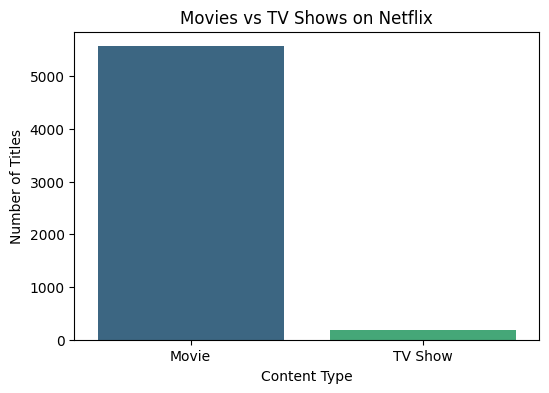

In [15]:
# Bar chart comparing Movies vs TV Shows
plt.figure(figsize=(6, 4))
sns.barplot(x=type_c.index, y=type_c.values, hue=type_c.index,
            palette='viridis', legend=False)
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')





**Observation:** Movies vastly outnumber TV shows in this catalogue - Movies make up about 97% of titles here, with TV shows a small minority. Netflix's library (in this snapshot) is overwhelmingly movie-first.

## Level 7: Where Does the Content Come From?

Netflix sources content from many countries.

**Your task:**
- Find the **Top 5 countries** with the highest number of titles.
- Show their contribution using a pie chart.

This will help us see which countries dominate the catalogue.

In [16]:
# A single title can list multiple countries (e.g. "United States, India"), so a
# straight value_counts() on the raw column would undercount real contributors.
# We split on ", " and explode so each country gets its own row before counting.
country_split = df['country'].str.split(', ').explode()
top5_countries = country_split.value_counts().head(5)
top5_countries


,count
country,
United States,2749
India,961
United Kingdom,537
Canada,317
France,311


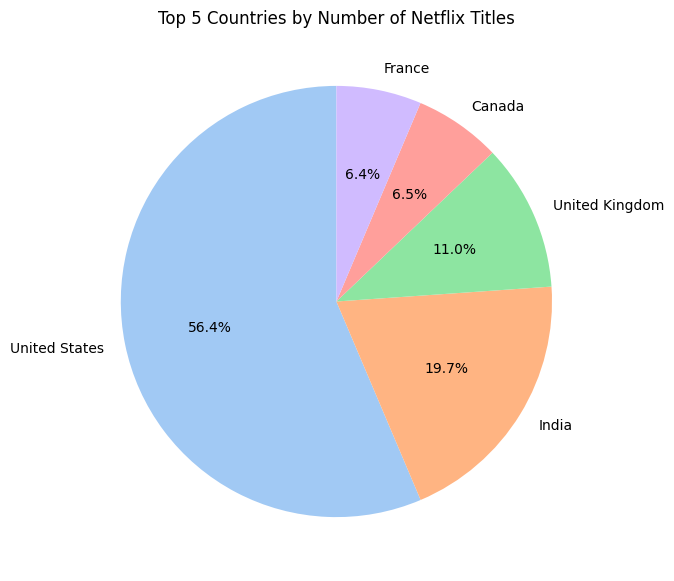

In [17]:
# Pie chart showing the Top 5 countries' share of titles
plt.figure(figsize=(7, 7))
plt.pie(top5_countries.values, labels=top5_countries.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('pastel'))
plt.title('Top 5 Countries by Number of Netflix Titles')
plt.show()


**Observation:** The United States dominates content origin, contributing over half of all titles (~56%), with India a distant second (~20%). Together the top 5 countries account for the large majority of the catalogue, showing fairly concentrated sourcing.

## Level 8: Genre Leaders by Country

Different genres may be led by different countries.

**Your task:**
- For each genre in `listed_in`, find the **country** that has produced the most titles in that genre.
- Print the results as a list (Genre -> Leading Country).

> Note: a title can belong to more than one genre - think about how you want to handle that before grouping.

In [18]:

genre_country = df[['listed_in', 'country']].copy()
genre_country['listed_in'] = genre_country['listed_in'].str.split(', ')
genre_country = genre_country.explode('listed_in')
genre_country['country'] = genre_country['country'].str.split(', ')
genre_country = genre_country.explode('country')

genre_country_counts = genre_country.groupby(['listed_in', 'country']).size().reset_index(name='count')
top_country_idx = genre_country_counts.groupby('listed_in')['count'].idxmax()
genre_leaders = genre_country_counts.loc[top_country_idx].sort_values('listed_in').reset_index(drop=True)

for _, row in genre_leaders.iterrows():
    print(f"{row['listed_in']} -> {row['country']} ({row['count']} titles)")


Action & Adventure -> United States (401 titles)
Anime Features -> Japan (61 titles)
Anime Series -> Japan (8 titles)
British TV Shows -> United Kingdom (22 titles)
Children & Family Movies -> United States (376 titles)
Classic & Cult TV -> United Kingdom (2 titles)
Classic Movies -> United States (81 titles)
Comedies -> United States (667 titles)
Crime TV Shows -> United States (22 titles)
Cult Movies -> United States (52 titles)
Documentaries -> United States (482 titles)
Docuseries -> United States (29 titles)
Dramas -> United States (830 titles)
Faith & Spirituality -> United States (42 titles)
Horror Movies -> United States (201 titles)
Independent Movies -> United States (389 titles)
International Movies -> India (854 titles)
International TV Shows -> Spain (13 titles)
Kids' TV -> United States (5 titles)
Korean TV Shows -> South Korea (10 titles)
LGBTQ Movies -> United States (59 titles)
Movies -> United States (14 titles)
Music & Musicals -> United States (142 titles)
Reality T

**Observation:** The United States leads in most Western genres (Action & Adventure, Comedies, Classic Movies), while India and Japan take the lead in region-specific genres - a good reminder that genre trends are strongly tied to where content is produced.

## Level 9: Netflix's Busiest Year

Netflix has grown its catalogue steadily over the years, but some years stand out more than others.

**Your task:**
- Group the data by `year_added`.
- Find the year in which Netflix added the **most titles** to its catalogue.

This shows us the point where the platform's library grew the fastest.

Netflix's busiest year for adding titles was 2019, with 1352 titles added.


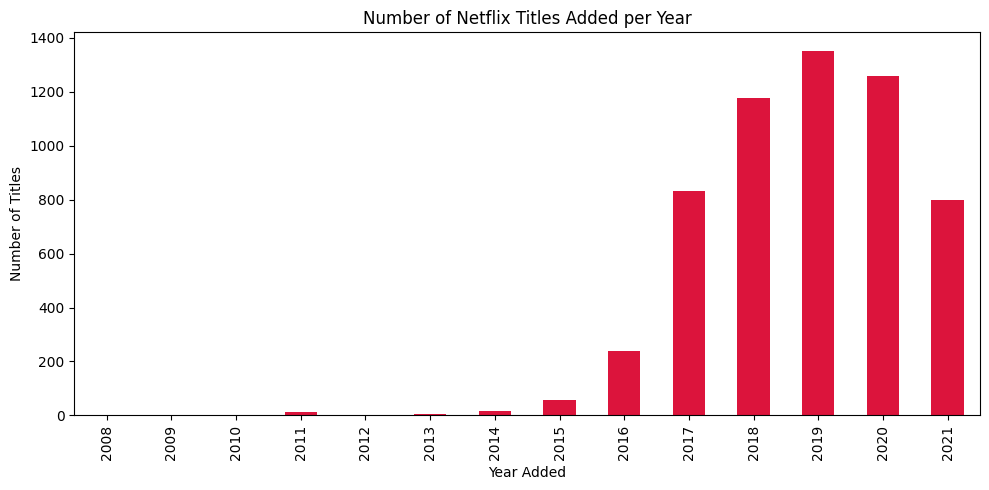

In [19]:
# Group by year_added and count titles per year to find Netflix's busiest year
titles_per_year = df.groupby('year_added').size().sort_values(ascending=False)
busiest_year = titles_per_year.idxmax()
print(f"Netflix's busiest year for adding titles was {int(busiest_year)}, "
      f"with {titles_per_year.max()} titles added.")

# Bar chart of titles added per year for context
plt.figure(figsize=(10, 5))
titles_per_year.sort_index().plot(kind='bar', color='crimson')
plt.title('Number of Netflix Titles Added per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()


**Observation:** Title additions ramped up sharply through the mid-2010s and peaked around 2019, before pulling back slightly in the following years - suggesting Netflix's most aggressive catalogue expansion phase has passed and growth has since leveled off.

## Final Task: Open Exploration

You have worked through each step above - now it's time to explore on your own.

**Your final task:**
- Choose any 2 to 3 plots of your own choice that reveal an interesting pattern in the data.

This is your creative zone - treat it as building your own short story from the dataset. When you are done, share your best plot and the observation behind it with the group.

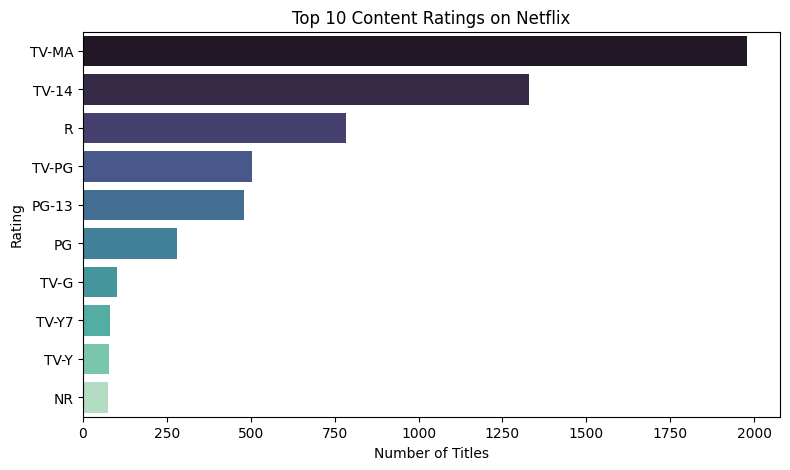

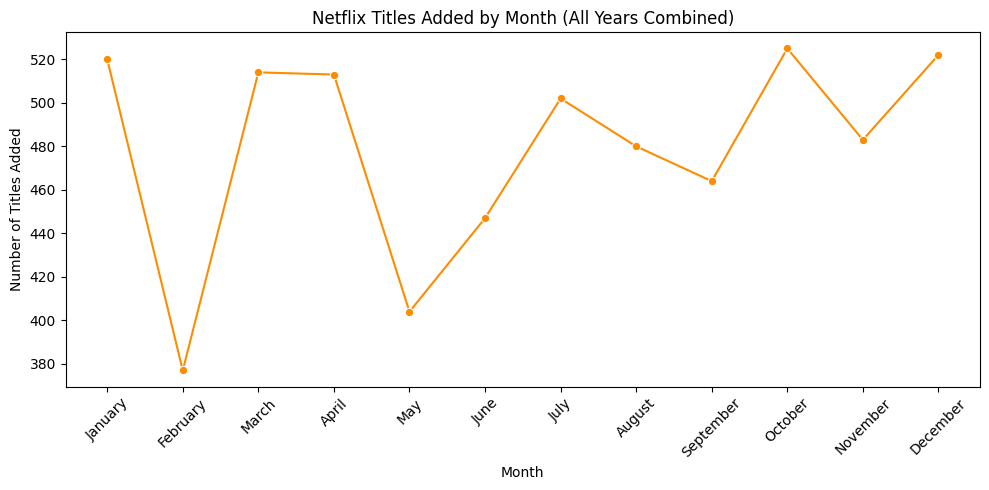

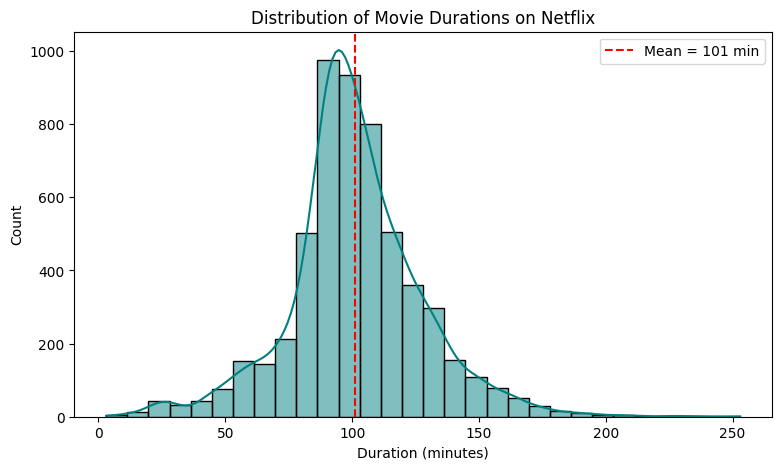

In [22]:
# --- Open Exploration: 3 plots of my own choice ---

# 1) Content Rating distribution - what audience is Netflix's catalogue mostly aimed at?

plt.figure(figsize=(9, 5))
rating_counts = df['rating'].value_counts().head(10)
sns.barplot(x=rating_counts.values, y=rating_counts.index, hue=rating_counts.index,
              palette='mako', legend=False)
plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.show()

# 2) Which month does Netflix add the most titles in? (seasonality check)
df['month_added'] = df['date_added'].dt.month_name()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_counts = df['month_added'].value_counts().reindex(month_order)

plt.figure(figsize=(10, 5))
sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o', color='darkorange')
plt.title('Netflix Titles Added by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) Movie duration distribution - how long are Netflix movies, typically?
plt.figure(figsize=(9, 5))
sns.histplot(movies['duration_mins'], bins=30, kde=True, color='teal')
plt.axvline(movies['duration_mins'].mean(), color='red', linestyle='--',
            label=f"Mean = {movies['duration_mins'].mean():.0f} min")
plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.legend()
plt.show()


**Observations from open exploration:**\n1. **Ratings:** `TV-MA` and `TV-14` dominate the rating distribution, confirming Netflix's catalogue skews toward mature/teen audiences rather than young children.\n2. **Seasonality:** Title additions are noticeably higher in December and January (and around October) than in mid-year months like June - possibly tied to holiday-season content pushes.\n3. **Movie length:** Most movies cluster tightly around 90-100 minutes, with a long right tail of a few much longer films - a fairly typical runtime distribution for mainstream cinema.